# Lesson 1.1 — What is CFD and Why Does It Exist?

## The Hook: The Weather Forecast Paradox

Every morning you check a weather app that tells you tomorrow's temperature. But how does it know?
The atmosphere is a fluid — air. Its behaviour is described by PDEs (the Navier-Stokes equations
plus thermodynamics). The forecast is literally a numerical solution of those equations over the
entire globe, updated every few hours on supercomputers.

That is CFD.

More broadly: **Computational Fluid Dynamics (CFD)** is the use of numerical methods and algorithms
to solve the governing equations of fluid flow on a computer.

---

## Why Can't We Just Use Formulas?

You can solve a few idealised cases analytically — Poiseuille flow in a circular pipe, Stokes flow
around a sphere, etc. But as soon as the geometry gets complex (an aircraft wing, a heart valve, a
turbine blade), analytical solutions don't exist. The PDEs become impossible to integrate by hand.

CFD sidesteps this by **discretizing** the domain:

- Break the fluid region into thousands (or millions) of small cells.
- Replace the continuous derivatives with algebraic approximations on the cell grid.
- Solve the resulting large sparse linear system numerically.

The mosaic analogy: a mosaic reproduces the Mona Lisa using only coloured square tiles. Each tile
is trivially simple. The combination captures the full picture. CFD does the same thing with physics.

---

## The Governing Equations

CFD solves the **Navier-Stokes equations** — Newton's second law for a fluid element:

**Continuity (mass conservation):**
$$\frac{\partial \rho}{\partial t} + \nabla \cdot (\rho \mathbf{u}) = 0$$

**Momentum:**
$$\rho \left( \frac{\partial \mathbf{u}}{\partial t} + \mathbf{u} \cdot \nabla \mathbf{u} \right) = -\nabla p + \mu \nabla^2 \mathbf{u} + \mathbf{f}$$

where $\rho$ is density, $\mathbf{u}$ is velocity, $p$ is pressure, $\mu$ is dynamic viscosity,
and $\mathbf{f}$ is body force (gravity, etc.).

These look intimidating. By the end of Module 02 you will have written code to solve them from scratch.

---

## A Brief History

| Year | Milestone |
|------|-----------|
| 1901 | Richardson proposes finite-difference weather forecasting (by hand!) |
| 1950 | First computer weather forecast (ENIAC, 24 hours to simulate 24 hours) |
| 1965 | Harlow & Welch invent the MAC method for incompressible N-S |
| 1972 | SIMPLE algorithm (Patankar & Spalding) — still used in ANSYS Fluent today |
| 1980s | Commercial CFD codes: FLUENT, STAR-CD appear |
| 1998 | OpenFOAM released as open-source |
| 2020s | ML-accelerated CFD, physics-informed neural networks (PINNs) |

---

## Where CFD Is Used

- **Aerospace**: wing design, engine combustion, re-entry heating
- **Automotive**: drag reduction, engine cooling, cabin ventilation
- **Energy**: wind turbines, nuclear reactor cooling, gas pipelines
- **Biomedical**: blood flow in arteries, drug delivery, ventilator design
- **Civil**: building wind loads, wildfire spread, urban air quality
- **Electronics**: CPU cooling, data center airflow
- **Climate**: ocean circulation, hurricane prediction

---

## The CFD Pipeline

Every CFD project follows this sequence — memorise it:

```
1. Pre-processing
   ├── Define geometry
   ├── Generate mesh
   └── Set boundary and initial conditions

2. Solver
   ├── Choose discretization scheme (FDM, FVM, FEM)
   ├── Set up linear system
   └── Iterate until convergence

3. Post-processing
   ├── Visualize: contours, streamlines, vectors
   └── Extract: drag, lift, heat flux, pressure drop
```

This curriculum covers all three stages.


/var/folders/j6/slfvk4c54yj6lt99pq5rjh8m0000gn/T/ipykernel_6868/1230580205.py:22: RuntimeWarning: invalid value encountered in divide
  W = U_inf * (Z + R**2 / np.where(mask, np.nan, Z))


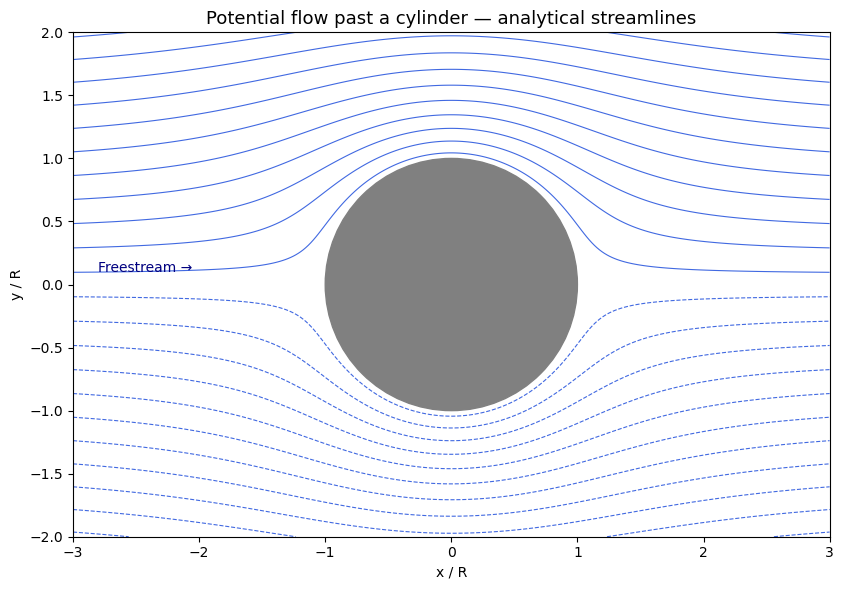

Notice: flow separates symmetrically (no viscosity = no wake).
A real CFD solve adds viscosity and turbulence — you'll get a Kármán vortex street.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Demo: visualizing a simple 2D potential flow (flow past a cylinder)
# This is NOT a CFD solve — it's an analytical solution for inviscid flow.
# We'll build the real thing in Module 02.

# Grid
x = np.linspace(-3, 3, 300)
y = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x, y)

# Cylinder radius
R = 1.0
U_inf = 1.0  # freestream speed

# Complex potential: w = U_inf * (z + R^2/z), z = x + iy
Z = X + 1j * Y
# Mask the cylinder interior
mask = (X**2 + Y**2) < R**2

W = U_inf * (Z + R**2 / np.where(mask, np.nan, Z))
phi = W.real   # velocity potential
psi = W.imag   # streamfunction

fig, ax = plt.subplots(figsize=(10, 6))
# Streamlines = contours of psi
levels = np.linspace(-2.5, 2.5, 30)
ax.contour(X, Y, psi, levels=levels, colors='royalblue', linewidths=0.8)

# Draw the cylinder
circle = plt.Circle((0, 0), R, color='grey', zorder=5)
ax.add_patch(circle)
ax.set_xlim(-3, 3)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.set_title('Potential flow past a cylinder — analytical streamlines', fontsize=13)
ax.set_xlabel('x / R')
ax.set_ylabel('y / R')
ax.annotate('Freestream →', xy=(-2.8, 0.1), fontsize=10, color='navy')
plt.tight_layout()
plt.show()

print("Notice: flow separates symmetrically (no viscosity = no wake).")
print("A real CFD solve adds viscosity and turbulence — you'll get a Kármán vortex street.")

## CFD vs. Analytical vs. Experiment

| Method | Cost | Speed | Handles complex geometry? | Accuracy |
|--------|------|-------|--------------------------|----------|
| Analytical | Free | Instant | No | Exact (where it applies) |
| Experiment | High | Days–weeks | Yes | Ground truth |
| CFD | Medium | Hours–days | Yes | Approximate (converges with refinement) |

CFD is most valuable when experiments are dangerous (nuclear, combustion), physically impossible
(full-scale aircraft testing at every design variant), or when you need to study many parameters quickly.

---

## Key Takeaways

- CFD converts continuous PDEs into a discrete system solvable on a computer.
- The governing equations are the **Navier-Stokes equations** — Newton's law for fluids.
- Every CFD problem follows three stages: pre-processing → solver → post-processing.
- The key trade-off: finer mesh = more accurate but more expensive.
- By Module 02 you will have written a complete incompressible N-S solver from scratch.

---

**Next**: Lesson 1.2 — Python tools for CFD (NumPy, Matplotlib, vectorized operations).
